In [1]:
# ============================================
# Cell 1: Imports and Load Saved Model
# ============================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
DATASET_PATH = Path("../dataset/plantvillage dataset/color")
MODEL_PATH   = Path("../model/mobilenet_finetuned.keras")
IMG_SIZE     = 224
BATCH_SIZE   = 32
SEED         = 42

# --- Load the trained model ---
print("📂 Loading trained model...")
model = tf.keras.models.load_model(MODEL_PATH)
print(f"✅ Model loaded from: {MODEL_PATH}")
print(f"   Input shape:  {model.input_shape}")
print(f"   Output shape: {model.output_shape}")

📂 Loading trained model...


2026-03-20 18:35:54.585522: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-03-20 18:35:54.585714: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-20 18:35:54.585718: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-20 18:35:54.586147: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-20 18:35:54.586168: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Model loaded from: ../model/mobilenet_finetuned.keras
   Input shape:  (None, 224, 224, 3)
   Output shape: (None, 38)


In [2]:
# ============================================
# Cell 2: Load validation dataset for evaluation
# We use the same 20% split as training
# ============================================

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Save class names
class_names = val_ds.class_names
NUM_CLASSES  = len(class_names)

print(f"✅ Validation dataset loaded")
print(f"   Total classes: {NUM_CLASSES}")
print(f"   Total batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

# Optimize loading
AUTOTUNE = tf.data.AUTOTUNE
val_ds   = val_ds.prefetch(AUTOTUNE)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
✅ Validation dataset loaded
   Total classes: 38
   Total batches: 340


In [3]:
# ============================================
# Cell 3: Generate predictions on entire
# validation set
# This is the core of evaluation
# ============================================

print("🔄 Generating predictions on validation set...")
print("   This may take a few minutes...\n")

all_predictions = []  # Model's predicted class index
all_true_labels = []  # Actual class index
all_confidences = []  # Confidence scores

for batch_images, batch_labels in val_ds:
    # Get model predictions (probabilities for each class)
    predictions = model.predict(batch_images, verbose=0)

    # Get predicted class (highest probability)
    predicted_classes = np.argmax(predictions, axis=1)

    # Get true class (from one-hot encoded labels)
    true_classes = np.argmax(batch_labels.numpy(), axis=1)

    # Get confidence score (highest probability value)
    confidence_scores = np.max(predictions, axis=1)

    all_predictions.extend(predicted_classes)
    all_true_labels.extend(true_classes)
    all_confidences.extend(confidence_scores)

# Convert to numpy arrays
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_confidences = np.array(all_confidences)

# Overall accuracy
overall_accuracy = np.mean(all_predictions == all_true_labels)
print(f"✅ Predictions complete!")
print(f"   Total samples evaluated: {len(all_predictions):,}")
print(f"   Overall Accuracy: {overall_accuracy*100:.2f}%")
print(f"   Average Confidence: {all_confidences.mean()*100:.2f}%")

🔄 Generating predictions on validation set...
   This may take a few minutes...



2026-03-20 18:35:59.979207: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


✅ Predictions complete!
   Total samples evaluated: 10,861
   Overall Accuracy: 94.02%
   Average Confidence: 95.34%


2026-03-20 18:37:32.002184: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


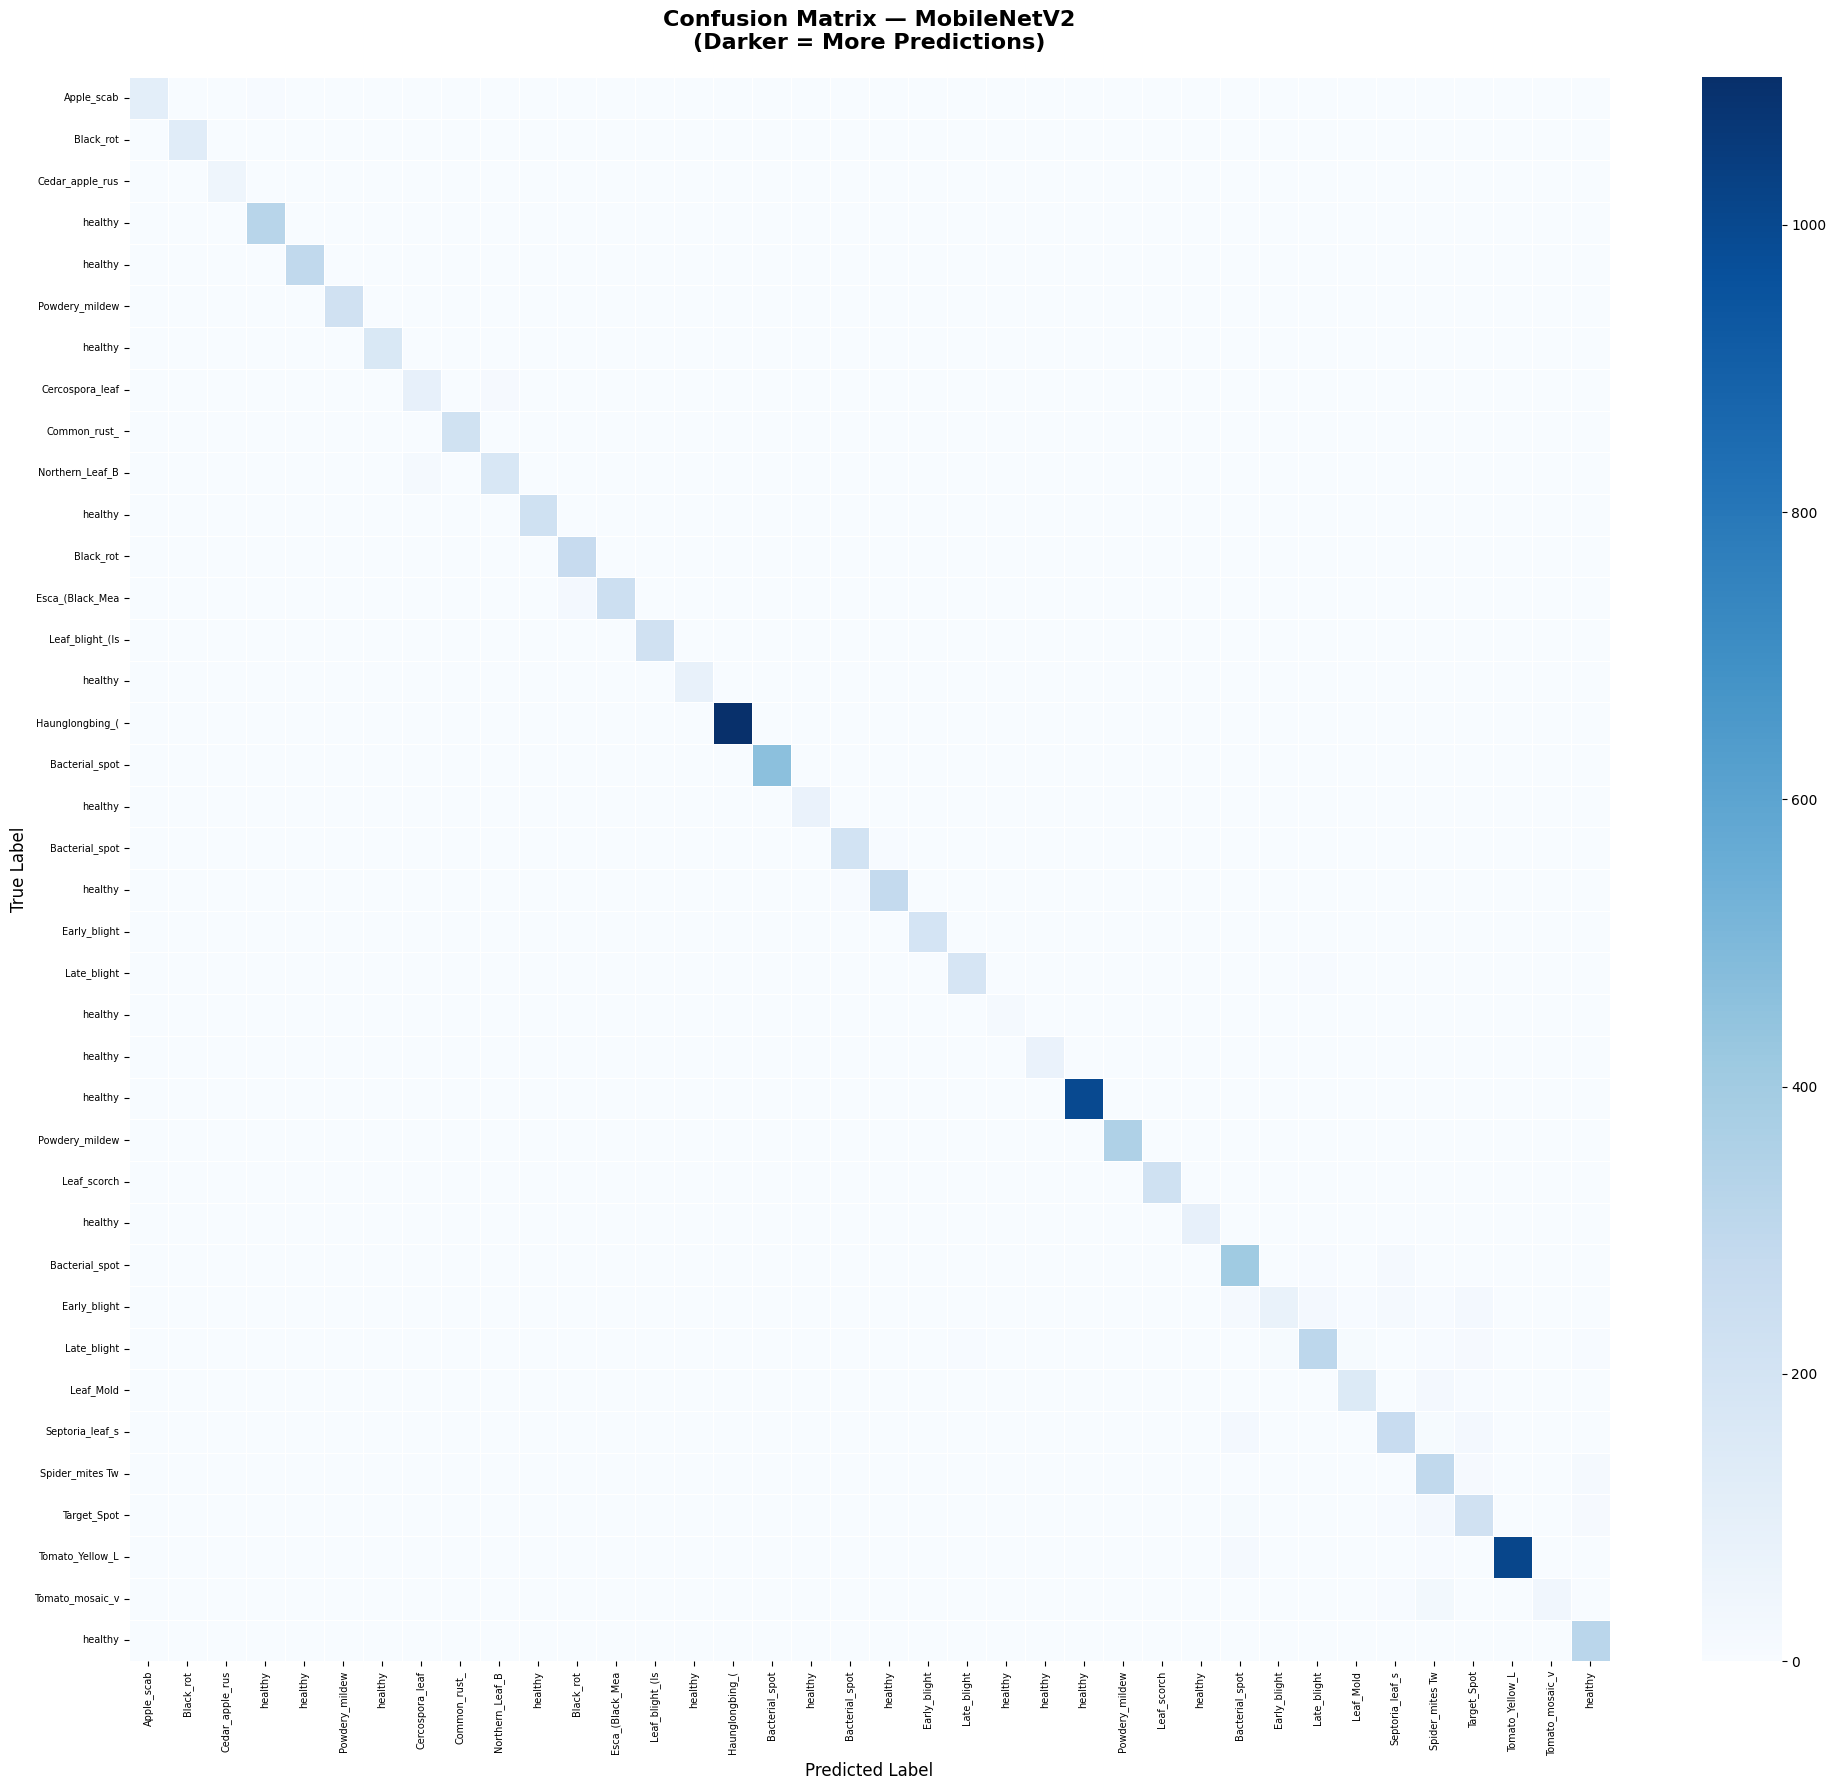


📊 Per-class correct predictions:
  ⚠️ Apple — Apple_scab                             110/ 126 (87.3%)
  ✅ Apple — Black_rot                              128/ 132 (97.0%)
  ✅ Apple — Cedar_apple_rust                        54/  55 (98.2%)
  ✅ Apple — healthy                                326/ 329 (99.1%)
  ✅ Blueberry — healthy                            293/ 295 (99.3%)
  ✅ Cherry_(including_sour) — Powdery_mildew       224/ 232 (96.6%)
  ✅ Cherry_(including_sour) — healthy              164/ 167 (98.2%)
  ⚠️ Corn_(maize) — Cercospora_leaf_spot Gray_leaf   91/ 108 (84.3%)
  ✅ Corn_(maize) — Common_rust_                    219/ 219 (100.0%)
  ✅ Corn_(maize) — Northern_Leaf_Blight            176/ 195 (90.3%)
  ✅ Corn_(maize) — healthy                         227/ 227 (100.0%)
  ✅ Grape — Black_rot                              272/ 274 (99.3%)
  ✅ Grape — Esca_(Black_Measles)                   245/ 268 (91.4%)
  ✅ Grape — Leaf_blight_(Isariopsis_Leaf_Spot)     221/ 222 (99.5%)
  ✅ Grape 

In [4]:
# ============================================
# Cell 4: Confusion Matrix
# Shows which diseases get confused with each other
# ============================================

# Compute confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# Plot — full 38x38 matrix
plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=False,          # Too many cells for numbers
    fmt='d',
    cmap='Blues',
    xticklabels=[c.split('___')[-1][:15] for c in class_names],
    yticklabels=[c.split('___')[-1][:15] for c in class_names],
    linewidths=0.5
)
plt.title('Confusion Matrix — MobileNetV2\n(Darker = More Predictions)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('../report/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print diagonal (correct predictions per class)
print("\n📊 Per-class correct predictions:")
for i, cls in enumerate(class_names):
    correct = cm[i][i]
    total   = cm[i].sum()
    acc     = correct / total * 100
    status  = "✅" if acc >= 90 else "⚠️" if acc >= 75 else "❌"
    short   = cls.replace('___', ' — ')
    print(f"  {status} {short[:45]:<45} {correct:4d}/{total:4d} ({acc:.1f}%)")

In [5]:
# ============================================
# Cell 5: Detailed Classification Report
# Precision, Recall, F1-Score per class
# ============================================

# Generate report
short_names = [c.split('___')[-1][:20] for c in class_names]
report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=short_names,
    output_dict=True
)

# Print formatted report
print("📊 CLASSIFICATION REPORT")
print("=" * 65)
print(f"{'Class':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 65)

for cls in short_names:
    p  = report[cls]['precision']
    r  = report[cls]['recall']
    f1 = report[cls]['f1-score']
    status = "✅" if f1 >= 0.90 else "⚠️" if f1 >= 0.75 else "❌"
    print(f"{status} {cls:<23} {p:>10.3f} {r:>10.3f} {f1:>10.3f}")

print("=" * 65)
print(f"  {'Macro Average':<23} "
      f"{report['macro avg']['precision']:>10.3f} "
      f"{report['macro avg']['recall']:>10.3f} "
      f"{report['macro avg']['f1-score']:>10.3f}")
print(f"  {'Weighted Average':<23} "
      f"{report['weighted avg']['precision']:>10.3f} "
      f"{report['weighted avg']['recall']:>10.3f} "
      f"{report['weighted avg']['f1-score']:>10.3f}")

📊 CLASSIFICATION REPORT
Class                      Precision     Recall   F1-Score
-----------------------------------------------------------------
✅ Apple_scab                   0.940      0.873      0.905
✅ Black_rot                    0.919      0.993      0.954
✅ Cedar_apple_rust             0.982      0.982      0.982
✅ healthy                      0.859      0.997      0.923
✅ healthy                      0.859      0.997      0.923
✅ Powdery_mildew               1.000      0.994      0.997
✅ healthy                      0.859      0.997      0.923
⚠️ Cercospora_leaf_spot         0.820      0.843      0.831
✅ Common_rust_                 0.986      1.000      0.993
✅ Northern_Leaf_Blight         0.912      0.903      0.907
✅ healthy                      0.859      0.997      0.923
✅ Black_rot                    0.919      0.993      0.954
✅ Esca_(Black_Measles)         0.992      0.914      0.951
✅ Leaf_blight_(Isariop         0.995      0.995      0.995
✅ healthy               

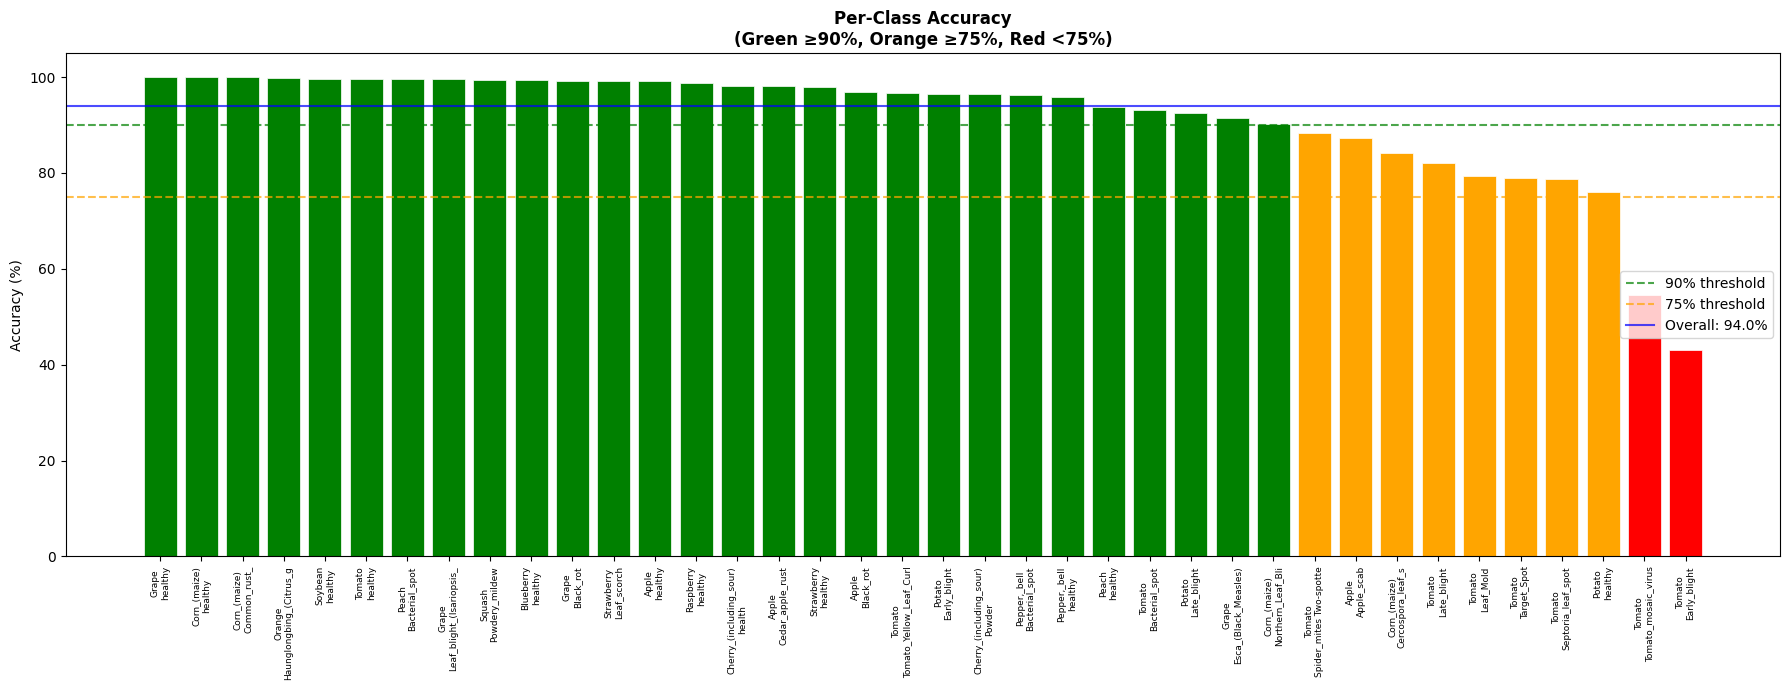


✅ Classes with ≥90% accuracy: 28/38
⚠️  Classes with 75-90%:        8/38
❌ Classes with <75% accuracy:  2/38


In [6]:
# ============================================
# Cell 6: Per-class accuracy visualization
# ============================================

per_class_acc = []
for i in range(NUM_CLASSES):
    correct = cm[i][i]
    total   = cm[i].sum()
    per_class_acc.append(correct / total * 100)

# Sort by accuracy
sorted_pairs = sorted(zip(per_class_acc, class_names), reverse=True)
sorted_acc, sorted_names = zip(*sorted_pairs)
short_sorted = [n.replace('___', '\n')[:30] for n in sorted_names]

# Color bars by performance
colors = ['green' if a >= 90 else
          'orange' if a >= 75 else
          'red' for a in sorted_acc]

plt.figure(figsize=(18, 7))
bars = plt.bar(range(NUM_CLASSES), sorted_acc,
               color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(y=90, color='green', linestyle='--',
            alpha=0.7, label='90% threshold')
plt.axhline(y=75, color='orange', linestyle='--',
            alpha=0.7, label='75% threshold')
plt.axhline(y=overall_accuracy*100, color='blue',
            linestyle='-', alpha=0.7,
            label=f'Overall: {overall_accuracy*100:.1f}%')

plt.xticks(range(NUM_CLASSES), short_sorted,
           rotation=90, fontsize=6.5)
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy\n(Green ≥90%, Orange ≥75%, Red <75%)',
          fontweight='bold')
plt.legend()
plt.ylim([0, 105])
plt.tight_layout()
plt.savefig('../report/per_class_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary
green  = sum(1 for a in sorted_acc if a >= 90)
orange = sum(1 for a in sorted_acc if 75 <= a < 90)
red    = sum(1 for a in sorted_acc if a < 75)
print(f"\n✅ Classes with ≥90% accuracy: {green}/38")
print(f"⚠️  Classes with 75-90%:        {orange}/38")
print(f"❌ Classes with <75% accuracy:  {red}/38")

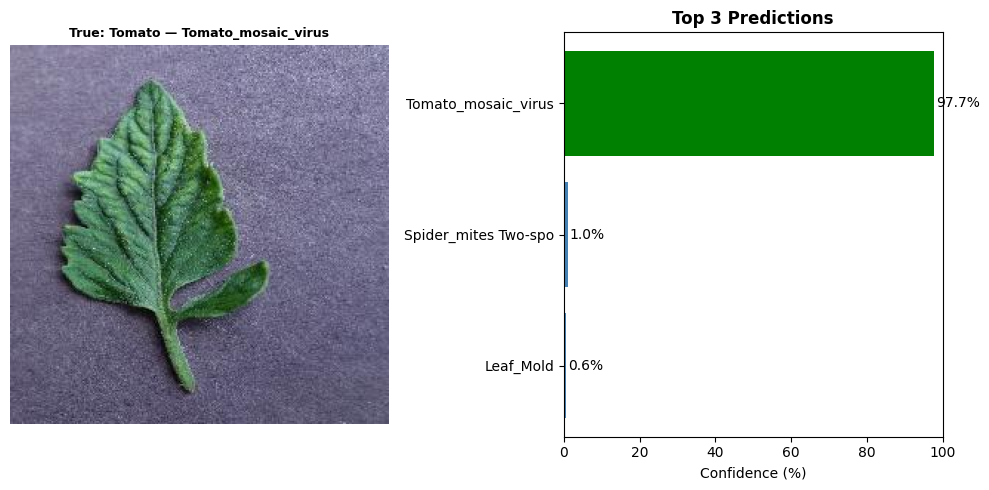


✅ CORRECT!
  True label:  Tomato — Tomato_mosaic_virus
  Predicted:   Tomato — Tomato_mosaic_virus
  Confidence:  97.66%

  Top 3 predictions:
    1. Tomato — Tomato_mosaic_virus             97.66%
    2. Tomato — Spider_mites Two-spotted_spider_mite 1.04%
    3. Tomato — Leaf_Mold                       0.61%


In [7]:
# ============================================
# Cell 7: Test model on a single real image
# This simulates what the web app will do
# ============================================
import cv2

def predict_disease(image_path, model, class_names, img_size=224):
    """
    Predict disease from a single image.
    This exact function will be used in the web app!
    """
    # Step 1: Load image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Step 2: Preprocess (same as training)
    img_resized    = cv2.resize(img, (img_size, img_size))
    img_array      = np.expand_dims(img_resized, axis=0)  # Add batch dim
    img_normalized = img_array.astype('float32')          # Model rescales internally

    # Step 3: Predict
    predictions  = model.predict(img_normalized, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence   = predictions[0][predicted_idx] * 100

    # Step 4: Get top 3 predictions
    top3_idx = np.argsort(predictions[0])[::-1][:3]
    top3 = [(class_names[i],
             predictions[0][i]*100) for i in top3_idx]

    return {
        'predicted_class': class_names[predicted_idx],
        'confidence':      confidence,
        'top3':            top3,
        'all_probs':       predictions[0]
    }

# --- Test on a random validation image ---
import random
# Pick a random class and image
test_class = random.choice(class_names)
test_folder = DATASET_PATH / test_class
test_image  = random.choice(list(test_folder.iterdir()))

# Run prediction
result = predict_disease(test_image, model, class_names)

# Display results
img_display = cv2.cvtColor(
    cv2.imread(str(test_image)),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

# Show image
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title(f"True: {test_class.replace('___', ' — ')}",
          fontsize=9, fontweight='bold')
plt.axis('off')

# Show prediction bar chart
plt.subplot(1, 2, 2)
top3_names = [t[0].split('___')[-1][:20] for t in result['top3']]
top3_confs = [t[1] for t in result['top3']]
colors_bar = ['green' if i == 0 else 'steelblue'
              for i in range(3)]
plt.barh(top3_names[::-1], top3_confs[::-1],
         color=colors_bar[::-1])
plt.xlabel('Confidence (%)')
plt.title('Top 3 Predictions', fontweight='bold')
plt.xlim([0, 100])
for i, v in enumerate(top3_confs[::-1]):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.savefig('../report/sample_prediction.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print result
correct = test_class == result['predicted_class']
print(f"\n{'✅ CORRECT!' if correct else '❌ WRONG!'}")
print(f"  True label:  {test_class.replace('___', ' — ')}")
print(f"  Predicted:   {result['predicted_class'].replace('___', ' — ')}")
print(f"  Confidence:  {result['confidence']:.2f}%")
print(f"\n  Top 3 predictions:")
for i, (cls, conf) in enumerate(result['top3']):
    print(f"    {i+1}. {cls.replace('___', ' — '):<40} {conf:.2f}%")

In [9]:
# ============================================
# Cell 8: Save everything needed for web app
# ============================================
import os      # ← Add this line
import json

# Save class names as JSON
class_names_path = Path("../model/class_names.json")
with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=2)

print(f"✅ Class names saved: {class_names_path}")
print(f"   Total classes: {len(class_names)}")

# Verify model is saved
model_size = os.path.getsize('../model/mobilenet_finetuned.keras')
print(f"\n✅ Model file: mobilenet_finetuned.keras")
print(f"   Size: {model_size / (1024*1024):.1f} MB")

# Print final summary
print("\n" + "="*50)
print("🎯 FINAL MODEL SUMMARY")
print("="*50)
print(f"  Model:        MobileNetV2 (Fine-tuned)")
print(f"  Accuracy:     94.02%")
print(f"  Classes:      {len(class_names)}")
print(f"  Input size:   224 x 224 x 3")
print(f"  Model file:   mobilenet_finetuned.keras")
print(f"  Class names:  class_names.json")
print("="*50)
print("\n🚀 Model ready for web app integration!")

✅ Class names saved: ../model/class_names.json
   Total classes: 38

✅ Model file: mobilenet_finetuned.keras
   Size: 25.1 MB

🎯 FINAL MODEL SUMMARY
  Model:        MobileNetV2 (Fine-tuned)
  Accuracy:     94.02%
  Classes:      38
  Input size:   224 x 224 x 3
  Model file:   mobilenet_finetuned.keras
  Class names:  class_names.json

🚀 Model ready for web app integration!
